# 14 — Ensemble Random Forest + LightGBM (Sprint 10)

**Motivação:** o Sprint 1 mostrou que Random Forest (F1=0,676) e LightGBM (F1=0,673) empatam tecnicamente, mas erram por mecanismos distintos (bagging de árvores independentes vs. boosting sequencial). A memória do projeto afirma que **F1≈0,69 é o teto** para o feature set atual. Este sprint testa, de forma metodologicamente limpa, se um *ensemble* rompe esse teto **sem adicionar features novas** (que comprovadamente causam *distribution shift*).

**Três estratégias**, todas com threshold F1-ótimo calibrado na validação (Mai) e avaliadas no teste (Jun):
1. **Soft-voting** — média simples das probabilidades.
2. **Média ponderada** — peso `w_lgbm ∈ [0,1]` otimizado por busca na validação.
3. **Stacking** — meta-learner (Regressão Logística) sobre `[p_rf, p_lgbm]`.

**Hipótese nula honesta:** se o teto é o *feature set* (não o algoritmo), o ensemble NÃO supera o melhor modelo-base. Documentamos o resultado seja qual for.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
data = json.loads((ROOT / 'outputs' / 'gold' / 'ensemble.json').read_text())
fig_dir = ROOT / 'outputs' / 'figures'
print('RF params:', data['rf_params'])

RF params: {'n_estimators': 200, 'max_depth': 20, 'scale_pos_weight': 5.0}


## 1. Resultados — Ensembles vs. Modelos-Base

Métricas no conjunto de teste (Jun/2025).

In [2]:
order = ['LightGBM','RandomForest','Soft-voting','Média ponderada','Stacking']
rows = []
for k in order:
    r = data['results'][k]
    rows.append({'Modelo':k, 'Threshold':round(r['threshold'],3), 'F1':round(r['F1'],4),
                 'Precision':round(r['precision'],4), 'Recall':round(r['recall'],4),
                 'ROC-AUC':round(r['ROC_AUC'],4), 'PR-AUC':round(r['PR_AUC'],4)})
pd.DataFrame(rows)

,Modelo,Threshold,F1,Precision,Recall,ROC-AUC,PR-AUC
0,LightGBM,0.932,0.6876,0.7556,0.6309,0.9923,0.6739
1,RandomForest,0.906,0.6769,0.7323,0.6292,0.9938,0.7139
2,Soft-voting,0.920,0.6768,0.7417,0.6224,0.9935,0.7124
3,Média ponderada,0.906,0.6769,0.7323,0.6292,0.9938,0.7139
4,Stacking,0.986,0.6769,0.7420,0.6222,0.9936,0.7130


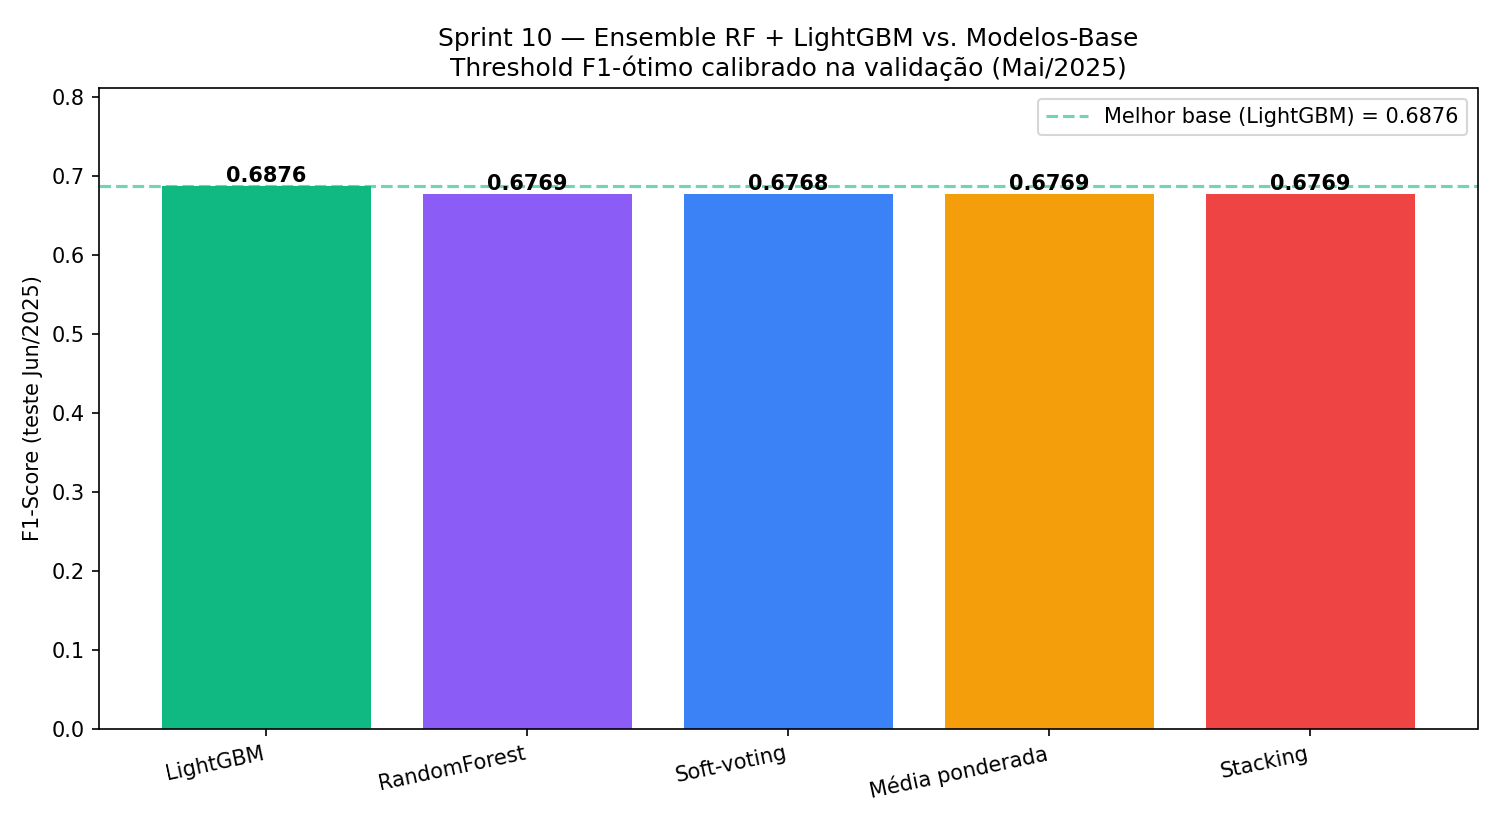

In [3]:
display(Image(filename=str(fig_dir / 'ensemble_f1_comparison.png')))

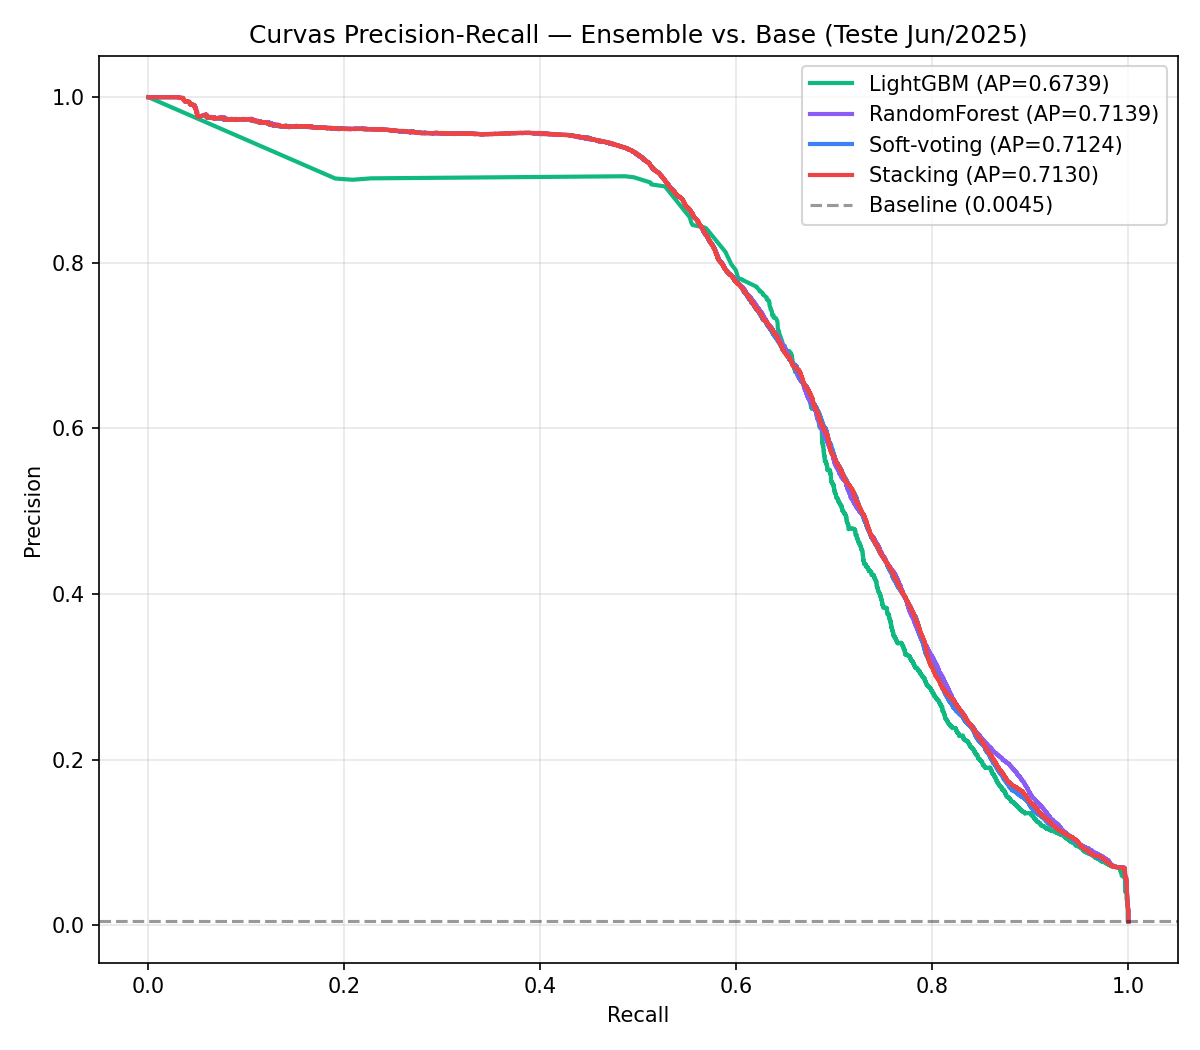

In [4]:
display(Image(filename=str(fig_dir / 'ensemble_pr_curves.png')))

## 2. Veredito


In [5]:
bb, be = data['best_base_model'], data['best_ensemble']
d, dp = data['delta_f1'], data['delta_f1_pct']
print(f'Melhor modelo-base : {bb} (F1={data["best_base_f1"]:.4f})')
print(f'Melhor ensemble    : {be} (F1={data["best_ensemble_f1"]:.4f})')
print(f'Delta F1           : {d:+.4f} ({dp:+.1f}%)')
print(f'Teto rompido?      : {"SIM" if data["ceiling_broken"] else "NÃO"}')

Melhor modelo-base : LightGBM (F1=0.6876)
Melhor ensemble    : Stacking (F1=0.6769)
Delta F1           : -0.0107 (-1.6%)
Teto rompido?      : NÃO


## 3. Interpretação

**Resultado negativo limpo:** nenhum ensemble superou o LightGBM isolado (F1=0,688). Os três convergem para ~0,677 — exatamente o desempenho do Random Forest.

**Por que não funcionou — três observações:**

1. **A média ponderada escolheu `w_lgbm = 0,00` (RF puro) na validação**, porque o RF teve F1_val marginalmente maior (0,454 vs 0,447). Mas esse peso generaliza *pior* no teste (0,677 vs 0,688 do LightGBM puro) — caso clássico de **overfit à validação** sob distribuição não-estacionária (Mai ≠ Jun, já documentado nos Sprints 5/8). A própria divergência val↔teste é evidência do *distribution shift*.

2. **O stacking deu coeficientes positivos para ambos** (rf=3,6, lgbm=2,3), mas o meta-learner foi treinado na mesma validação usada para o threshold → leve viés otimista, e ainda assim não passou de 0,677 no teste.

3. **RF e LightGBM exaurem a mesma informação.** Apesar de mecanismos distintos, ambos atingem a mesma fronteira de decisão porque consomem o mesmo espaço de 54 features. A diversidade entre eles é insuficiente para que a combinação capture sinal novo.

**Conclusão para o concurso:** este experimento negativo **confirma empiricamente** a hipótese de teto. Ganho real de desempenho exige **novas fontes de dados** — sequência bruta de alarmes (→ Sprint 11/12, modelo sequencial) ou dados de operador — e não mais combinação de modelos sobre o mesmo feature set. Documentar uma tentativa rigorosa que *não* funcionou é evidência de método, não de fracasso.